# Hair Diseases Classification (10 Classes) - All Models in One

DenseNet121 / MobileNet / ResNet50 (Plain + Transfer Learning), KerasTuner, Ensemble and Knowledge Distillation.

Dataset uses a fixed `train/` and `test/` directory structure. A validation split is carved out of `train/`.

### 1. Import Required Libraries

In [1]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import DenseNet121, MobileNet, ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)

print(f'TensorFlow Version: {tf.__version__}')

TensorFlow Version: 2.20.0


### 2. Experiment Configuration

In [2]:
class Config:
    # Fixed train / test directories for the 10-class hair disease dataset
    BASE_DIR = '/kaggle/input/datasets/sundarannamalai/hair-diseases/Hair Diseases - Final'
    TRAIN_DIR = os.path.join(BASE_DIR, 'train')
    TEST_DIR = os.path.join(BASE_DIR, 'test')

    IMAGE_SIZE = 224
    CHANNELS = 3
    INPUT_SHAPE = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
    BATCH_SIZE = 32
    EPOCHS = 30                # upper bound; EarlyStopping usually stops sooner
    FINE_TUNE_EPOCHS = 15      # second phase for transfer-learning fine-tuning
    VAL_SPLIT = 0.15           # validation carved from the train directory
    LR_SCRATCH = 1e-3
    LR_TRANSFER = 1e-4
    RANDOM_STATE = 42
    NUM_CLASSES = None         # auto-filled from the data generators below

config = Config()

In [3]:
# Global registry that every evaluation writes into
master_metrics_registry = {}

### 3. Reproducibility & GPU Setup

In [4]:
random.seed(config.RANDOM_STATE)
np.random.seed(config.RANDOM_STATE)
tf.random.set_seed(config.RANDOM_STATE)

# Allow GPU memory to grow instead of pre-allocating everything
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print(e)
print(f'GPUs available: {len(gpus)}')

GPUs available: 1


### 4. Data Streaming Generators (train / val / test)

In [5]:
# Augmentation for training; validation split is carved from the train folder.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=config.VAL_SPLIT,
)

# No augmentation for validation / test - only rescaling.
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=config.VAL_SPLIT)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    config.TRAIN_DIR,
    target_size=(config.IMAGE_SIZE, config.IMAGE_SIZE),
    batch_size=config.BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=config.RANDOM_STATE,
)

validation_generator = val_datagen.flow_from_directory(
    config.TRAIN_DIR,
    target_size=(config.IMAGE_SIZE, config.IMAGE_SIZE),
    batch_size=config.BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=config.RANDOM_STATE,
)

test_generator = test_datagen.flow_from_directory(
    config.TEST_DIR,
    target_size=(config.IMAGE_SIZE, config.IMAGE_SIZE),
    batch_size=config.BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)

# Fill in class metadata for the rest of the notebook
config.NUM_CLASSES = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
print(f'Number of classes: {config.NUM_CLASSES}')
print(f'Class names: {class_names}')

Found 8160 images belonging to 10 classes.
Found 1440 images belonging to 10 classes.
Found 1200 images belonging to 10 classes.
Number of classes: 10
Class names: ['Alopecia Areata', 'Contact Dermatitis', 'Folliculitis', 'Head Lice', 'Lichen Planus', 'Male Pattern Baldness', 'Psoriasis', 'Seborrheic Dermatitis', 'Telogen Effluvium', 'Tinea Capitis']


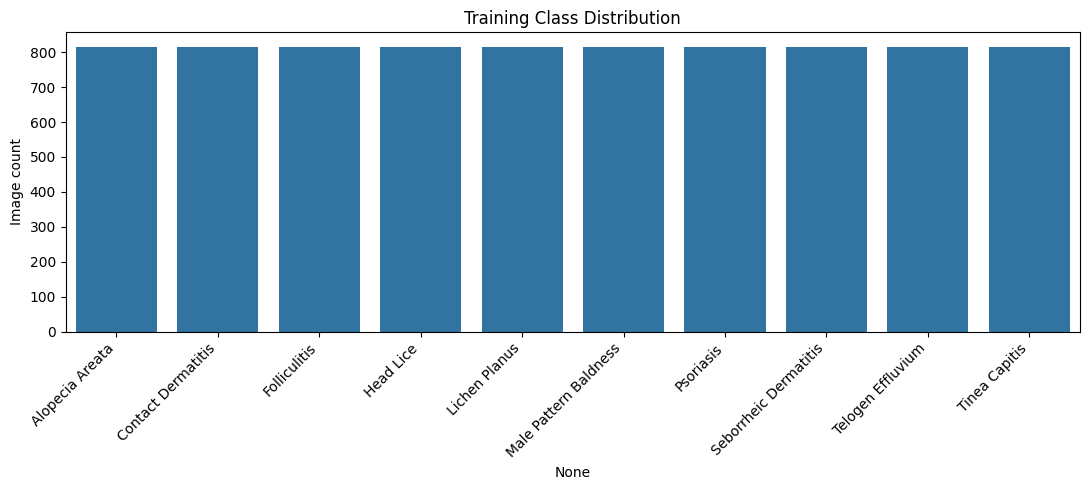

In [6]:
# Visualize the class distribution in the training set
idx_to_name = {v: k for k, v in train_generator.class_indices.items()}
counts = pd.Series(train_generator.classes).map(idx_to_name).value_counts()

plt.figure(figsize=(11, 5))
sns.barplot(x=counts.index, y=counts.values, color='#1f77b4')
plt.title('Training Class Distribution')
plt.ylabel('Image count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
# Balanced class weights to counter any class imbalance
labels = train_generator.classes
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels,
)
class_weights = dict(enumerate(weights))
print('Class weights:', class_weights)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0), 9: np.float64(1.0)}


### 5. Reusable Helpers (callbacks, model builder, trainer)

In [8]:
def get_callbacks():
    """EarlyStopping + LR scheduling to avoid wasting epochs."""
    return [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ]


def build_model(base_class, deep_head=False):
    """Build a transfer-learning model with a frozen ImageNet backbone.

    deep_head=False -> single GAP + softmax (the 'Plain' variant)
    deep_head=True  -> extra Dense/Dropout stack (the 'Transfer Learning' variant)
    Returns (model, base_model) so the caller can unfreeze for fine-tuning.
    """
    base_model = base_class(
        weights='imagenet', include_top=False, input_shape=config.INPUT_SHAPE
    )
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    if deep_head:
        x = Dense(512, activation='relu')(x)
        x = Dropout(0.5)(x)
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.5)(x)
    outputs = Dense(config.NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=outputs)
    return model, base_model


def train_model(model, epochs=None, class_weight=None):
    """Standard fit with shared callbacks."""
    return model.fit(
        train_generator,
        epochs=epochs or config.EPOCHS,
        validation_data=validation_generator,
        class_weight=class_weight,
        callbacks=get_callbacks(),
        verbose=1,
    )

### 6. Evaluation Engine (multiclass)

In [9]:
def evaluate_and_plot(model, history, model_name):
    # ---------------------------------------------------------------
    # 1. Predictions + latency timing
    # ---------------------------------------------------------------
    if hasattr(test_generator, 'reset'):
        test_generator.reset()

    start_time = time.time()
    y_pred_probs = model.predict(test_generator, verbose=0)
    inference_time = (time.time() - start_time) / len(test_generator.filenames)

    y_true = test_generator.classes
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    # Test loss via the model's own compiled loss (skip for non-Keras wrappers)
    test_loss = np.nan
    if isinstance(model, tf.keras.Model):
        try:
            if hasattr(test_generator, 'reset'):
                test_generator.reset()
            eval_results = model.evaluate(test_generator, verbose=0)
            test_loss = eval_results[0] if isinstance(eval_results, (list, tuple)) else eval_results
        except Exception:
            test_loss = np.nan

    # ---------------------------------------------------------------
    # 2. Metrics (weighted for multiclass)
    # ---------------------------------------------------------------
    acc = accuracy_score(y_true, y_pred_classes)
    pre = precision_score(y_true, y_pred_classes, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred_classes, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred_classes, average='weighted', zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_pred_probs, multi_class='ovr', average='weighted')
    except Exception:
        auc = np.nan

    latency_ms = inference_time * 1000

    print(f'\n================ {model_name} RESULTS ================')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Loss:      {test_loss:.4f}' if not pd.isna(test_loss) else 'Loss:      N/A')
    print(f'Precision: {pre:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1-Score:  {f1:.4f}')
    print(f'AUC Score: {auc:.4f}' if not pd.isna(auc) else 'AUC Score: N/A')
    print(f'Latency:   {latency_ms:.2f} ms/image')
    print('======================================================')

    # ---------------------------------------------------------------
    # 3. Plots
    # ---------------------------------------------------------------
    # A. Confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # B. Micro-average one-vs-rest ROC curve
    if not pd.isna(auc):
        try:
            classes_idx = list(range(config.NUM_CLASSES))
            y_true_bin = label_binarize(y_true, classes=classes_idx)
            fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_probs.ravel())
            plt.figure(figsize=(5, 4))
            plt.plot(fpr, tpr, color='darkorange', lw=2,
                     label=f'Micro-avg ROC (AUC = {auc:.4f})')
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
                     label='Random Classifier')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'{model_name} ROC Curve (One-vs-Rest)')
            plt.legend(loc='lower right')
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.show()
        except Exception as e:
            print(f'ROC plot skipped: {e}')

    # C. Training history
    if history is not None and hasattr(history, 'history'):
        train_acc = history.history.get('accuracy', history.history.get('acc', []))
        val_acc = history.history.get('val_accuracy', history.history.get('val_acc', []))
        train_loss = history.history.get('loss', [])
        val_loss = history.history.get('val_loss', [])

        if len(train_acc) > 0:
            epochs_range = range(1, len(train_acc) + 1)
            plt.figure(figsize=(6, 4))
            plt.plot(epochs_range, train_acc, label='Train Accuracy', color='blue', marker='o')
            if len(val_acc) > 0:
                plt.plot(epochs_range, val_acc, label='Val Accuracy', color='orange', marker='x')
            plt.title(f'{model_name} Epoch vs Accuracy')
            plt.xlabel('Epochs')
            plt.ylabel('Accuracy')
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.show()

        if len(train_loss) > 0:
            epochs_range = range(1, len(train_loss) + 1)
            plt.figure(figsize=(6, 4))
            plt.plot(epochs_range, train_loss, label='Train Loss', color='darkred', marker='o')
            if len(val_loss) > 0:
                plt.plot(epochs_range, val_loss, label='Val Loss', color='crimson', marker='x')
            plt.title(f'{model_name} Epoch vs Loss')
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.show()

    # ---------------------------------------------------------------
    # 4. Record payload
    # ---------------------------------------------------------------
    metrics_payload = {
        'Model Name': model_name,
        'Accuracy': float(acc),
        'Loss': float(test_loss) if not pd.isna(test_loss) else None,
        'Precision': float(pre),
        'Recall': float(rec),
        'F1-Score': float(f1),
        'ROC-AUC': float(auc) if not pd.isna(auc) else None,
        'Inference Time (ms/img)': float(latency_ms),
        'model_object': model,
        'history_object': history,
    }

    if 'master_metrics_registry' in globals():
        globals()['master_metrics_registry'][model_name] = metrics_payload

    return metrics_payload

### 7. DenseNet121 - Plain (frozen backbone)

I0000 00:00:1783973778.840363      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
  2/255 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.1641 - loss: 2.8233   

I0000 00:00:1783973815.950145      91 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


255/255 ━━━━━━━━━━━━━━━━━━━━ 205s 682ms/step - accuracy: 0.4938 - loss: 1.4841 - val_accuracy: 0.7222 - val_loss: 0.9203 - learning_rate: 0.0010
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 123s 483ms/step - accuracy: 0.7349 - loss: 0.8578 - val_accuracy: 0.7910 - val_loss: 0.6561 - learning_rate: 0.0010
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 122s 479ms/step - accuracy: 0.8066 - loss: 0.6522 - val_accuracy: 0.8458 - val_loss: 0.5218 - learning_rate: 0.0010
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 122s 480ms/step - accuracy: 0.8502 - loss: 0.5404 - val_accuracy: 0.9028 - val_loss: 0.4037 - learning_rate: 0.0010
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 121s 474ms/step - accuracy: 0.8806 - loss: 0.4530 - val_accuracy: 0.9160 - val_loss: 0.3320 - learning_rate: 0.0010
Epoch 6/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 120s 472ms/step - accuracy: 0.8938 - loss: 0.4018 - val_accuracy: 0.9229 - val_loss: 0.3086 - learning_rate: 0.0010
Epoch 7/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 122s 478ms/step - accuracy: 0.9076 

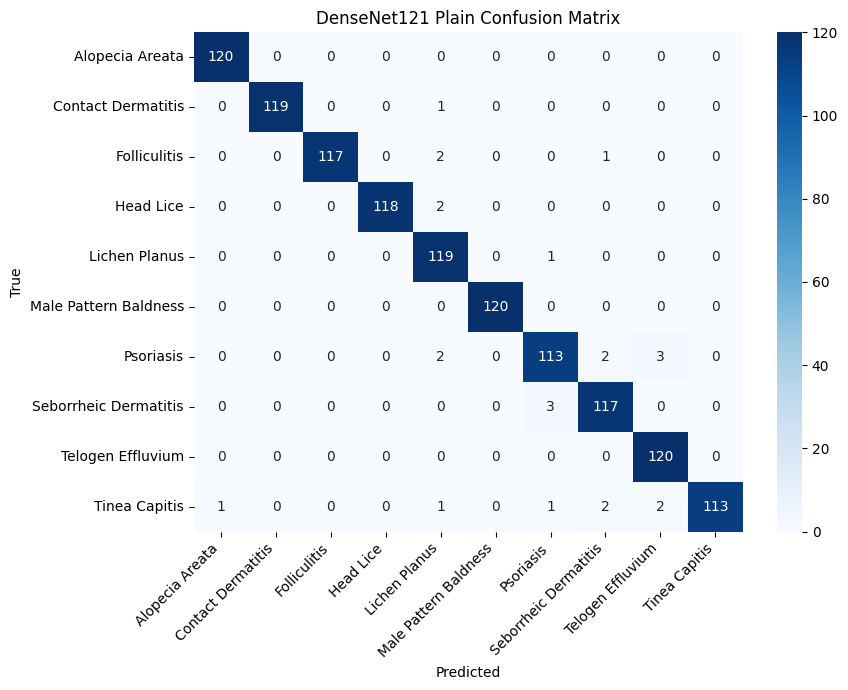

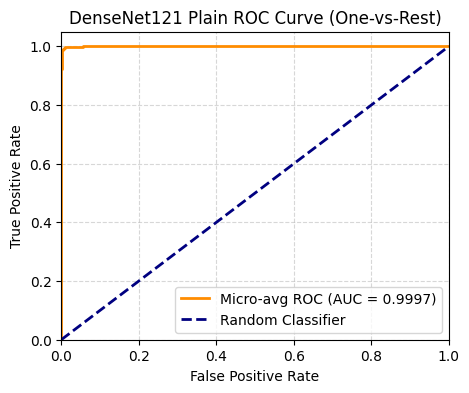

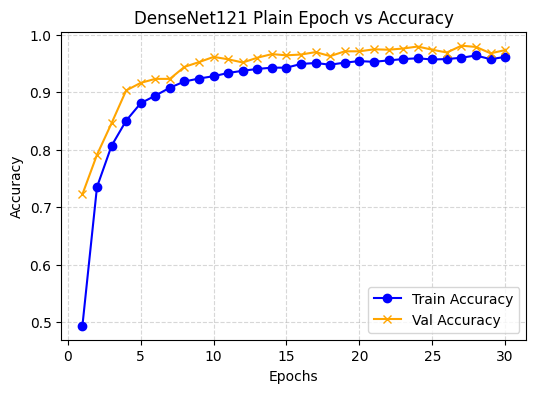

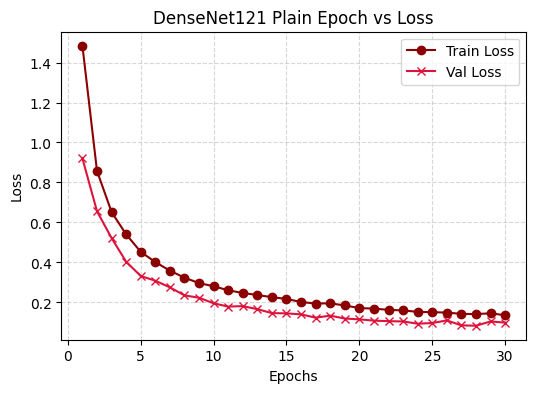

In [10]:
model_densenet, base_dn = build_model(DenseNet121, deep_head=False)
model_densenet.compile(optimizer=Adam(learning_rate=config.LR_SCRATCH),
                       loss='categorical_crossentropy', metrics=['accuracy'])

history_densenet = train_model(model_densenet, class_weight=class_weights)

master_metrics_registry['DenseNet121 Plain'] = evaluate_and_plot(
    model_densenet, history_densenet, 'DenseNet121 Plain')

### 8. DenseNet121 - Transfer Learning (head warm-up + fine-tune)

Epoch 1/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 164s 532ms/step - accuracy: 0.3663 - loss: 1.8000 - val_accuracy: 0.6514 - val_loss: 1.0063 - learning_rate: 0.0010
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 122s 476ms/step - accuracy: 0.6110 - loss: 1.1063 - val_accuracy: 0.7958 - val_loss: 0.5844 - learning_rate: 0.0010
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 121s 475ms/step - accuracy: 0.7188 - loss: 0.8026 - val_accuracy: 0.8813 - val_loss: 0.3847 - learning_rate: 0.0010
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 122s 478ms/step - accuracy: 0.7765 - loss: 0.6649 - val_accuracy: 0.9278 - val_loss: 0.2410 - learning_rate: 0.0010
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 125s 490ms/step - accuracy: 0.8154 - loss: 0.5426 - val_accuracy: 0.9257 - val_loss: 0.2072 - learning_rate: 0.0010
Epoch 6/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 126s 491ms/step - accuracy: 0.8468 - loss: 0.4477 - val_accuracy: 0.9458 - val_loss: 0.1604 - learning_rate: 0.0010
Epoch 7/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 122s 479ms/step - accura

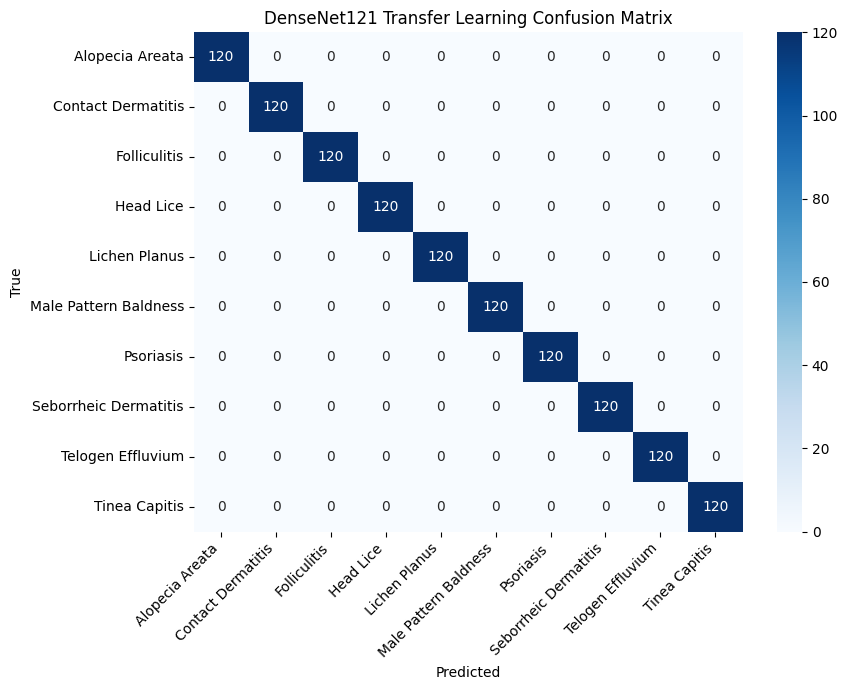

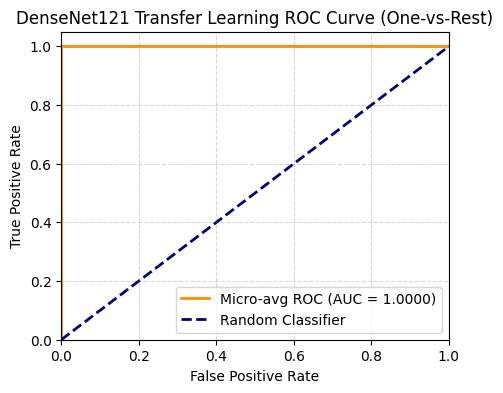

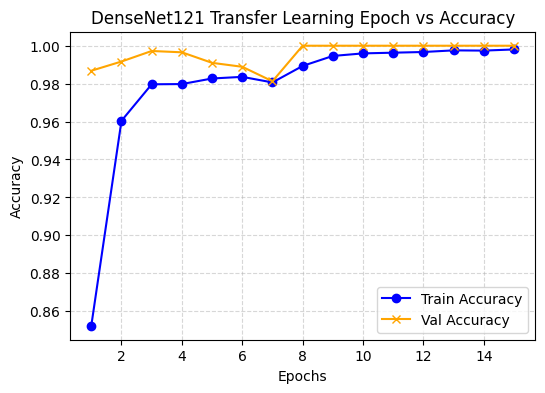

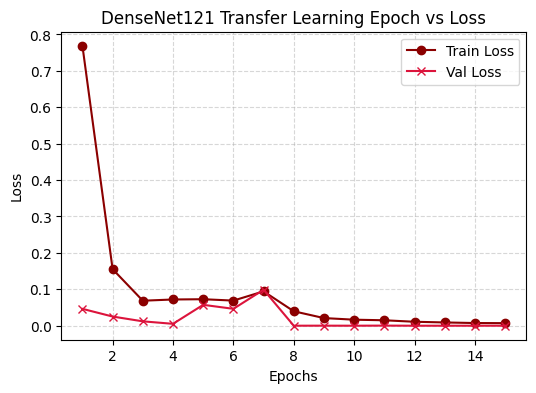

In [11]:
model_densenet_tl, base_dn_tl = build_model(DenseNet121, deep_head=True)
model_densenet_tl.compile(optimizer=Adam(learning_rate=config.LR_SCRATCH),
                          loss='categorical_crossentropy', metrics=['accuracy'])

# Phase 1: train the head with the backbone frozen
history_densenet_initial = train_model(model_densenet_tl, class_weight=class_weights)

# Phase 2: unfreeze and fine-tune with a low learning rate
base_dn_tl.trainable = True
model_densenet_tl.compile(optimizer=Adam(learning_rate=config.LR_TRANSFER),
                          loss='categorical_crossentropy', metrics=['accuracy'])
history_densenet_fine = train_model(
    model_densenet_tl, epochs=config.FINE_TUNE_EPOCHS, class_weight=class_weights)

master_metrics_registry['DenseNet121 Transfer Learning'] = evaluate_and_plot(
    model_densenet_tl, history_densenet_fine, 'DenseNet121 Transfer Learning')

### 9. MobileNet - Plain

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 130s 474ms/step - accuracy: 0.6039 - loss: 1.2304 - val_accuracy: 0.8590 - val_loss: 0.5740 - learning_rate: 0.0010
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 118s 462ms/step - accuracy: 0.8560 - loss: 0.5381 - val_accuracy: 0.9118 - val_loss: 0.3432 - learning_rate: 0.0010
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 118s 461ms/step - accuracy: 0.9200 - loss: 0.3542 - val_accuracy: 0.9569 - val_loss: 0.2194 - learning_rate: 0.0010
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 119s 465ms/step - accuracy: 0.9429 - loss: 0.2630 - val_accuracy: 0.9715 - val_loss: 0.1625 - learning_rate: 0.0010
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 120s 471ms/step - accuracy: 0.9537 - loss: 0.2114 - val_accuracy: 0.9736 - val_loss: 0.1386 - learning_rate: 0.0010
Epoch 6/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 118s 462ms/step - accuracy: 0.9616 - loss: 0.1780 - val_accuracy: 0.9799 - val_loss: 0.1070 - learning_rate: 0.0010
Epoch 7/30
25

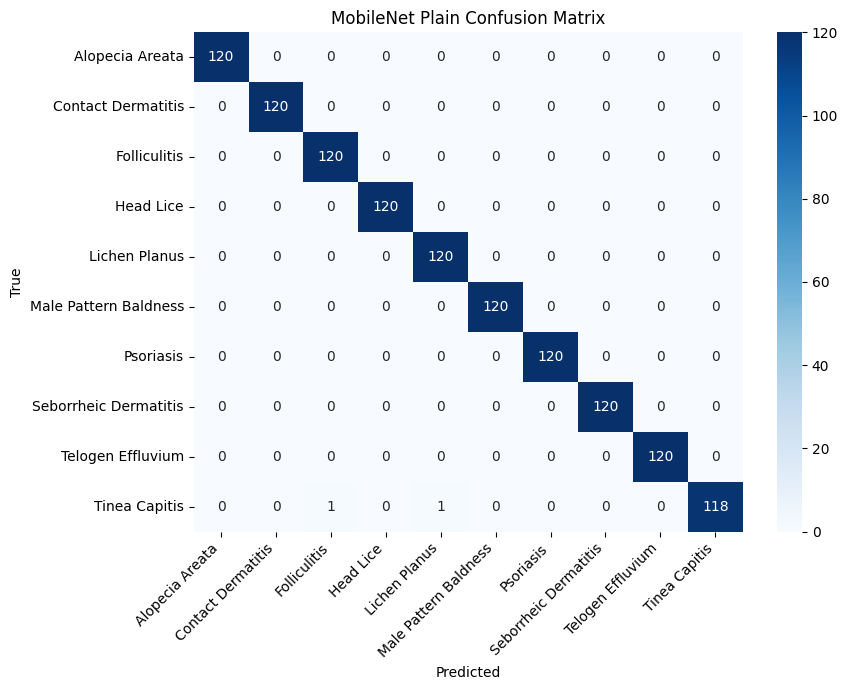

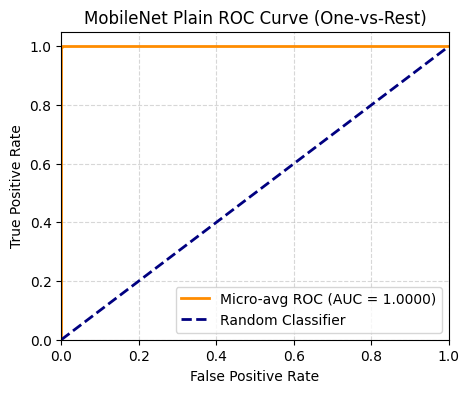

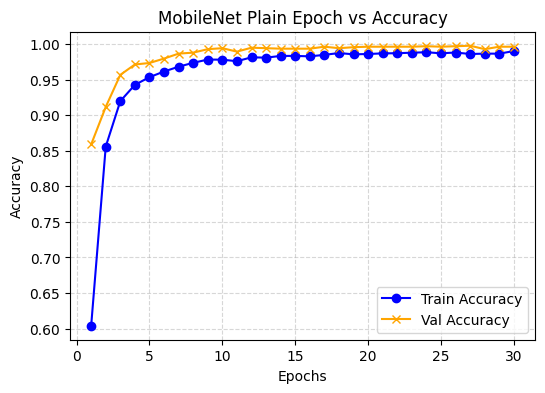

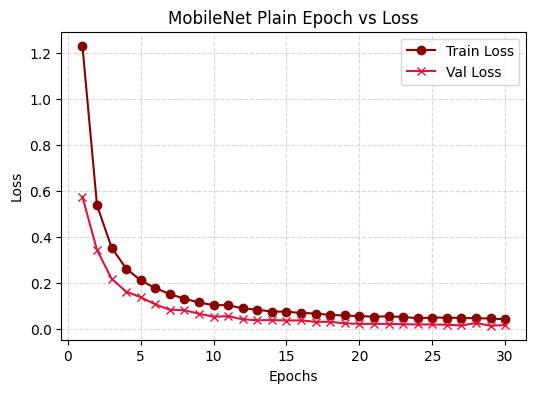

In [12]:
model_mobilenet, base_mb = build_model(MobileNet, deep_head=False)
model_mobilenet.compile(optimizer=Adam(learning_rate=config.LR_SCRATCH),
                        loss='categorical_crossentropy', metrics=['accuracy'])

history_mobilenet = train_model(model_mobilenet, class_weight=class_weights)

master_metrics_registry['MobileNet Plain'] = evaluate_and_plot(
    model_mobilenet, history_mobilenet, 'MobileNet Plain')

### 10. MobileNet - Transfer Learning

Epoch 1/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 132s 486ms/step - accuracy: 0.4445 - loss: 1.6002 - val_accuracy: 0.8208 - val_loss: 0.6728 - learning_rate: 0.0010
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 125s 489ms/step - accuracy: 0.7206 - loss: 0.8098 - val_accuracy: 0.9160 - val_loss: 0.2885 - learning_rate: 0.0010
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 124s 488ms/step - accuracy: 0.8267 - loss: 0.5139 - val_accuracy: 0.9625 - val_loss: 0.1243 - learning_rate: 0.0010
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 121s 474ms/step - accuracy: 0.8749 - loss: 0.3861 - val_accuracy: 0.9812 - val_loss: 0.0683 - learning_rate: 0.0010
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 118s 463ms/step - accuracy: 0.8993 - loss: 0.3088 - val_accuracy: 0.9861 - val_loss: 0.0532 - learning_rate: 0.0010
Epoch 6/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 115s 452ms/step - accuracy: 0.9185 - loss: 0.2542 - val_accuracy: 0.9882 - val_loss: 0.0411 - learning_rate: 0.0010
Epoch 7/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 119s 467ms/step - accura

2026-07-14 00:39:45.974531: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-14 00:39:46.175184: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


255/255 ━━━━━━━━━━━━━━━━━━━━ 158s 489ms/step - accuracy: 0.8691 - loss: 0.5883 - val_accuracy: 0.9785 - val_loss: 0.0716 - learning_rate: 1.0000e-04
Epoch 2/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 121s 475ms/step - accuracy: 0.9556 - loss: 0.1468 - val_accuracy: 0.9965 - val_loss: 0.0139 - learning_rate: 1.0000e-04
Epoch 3/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 119s 467ms/step - accuracy: 0.9750 - loss: 0.0925 - val_accuracy: 0.9965 - val_loss: 0.0113 - learning_rate: 1.0000e-04
Epoch 4/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 120s 469ms/step - accuracy: 0.9858 - loss: 0.0580 - val_accuracy: 1.0000 - val_loss: 9.4889e-04 - learning_rate: 1.0000e-04
Epoch 5/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 121s 473ms/step - accuracy: 0.9811 - loss: 0.0682 - val_accuracy: 0.9931 - val_loss: 0.0594 - learning_rate: 1.0000e-04
Epoch 6/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 119s 468ms/step - accuracy: 0.9827 - loss: 0.0604 - val_accuracy: 0.9937 - val_loss: 0.0190 - learning_rate: 1.0000e-04
Epoch 7/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 458m

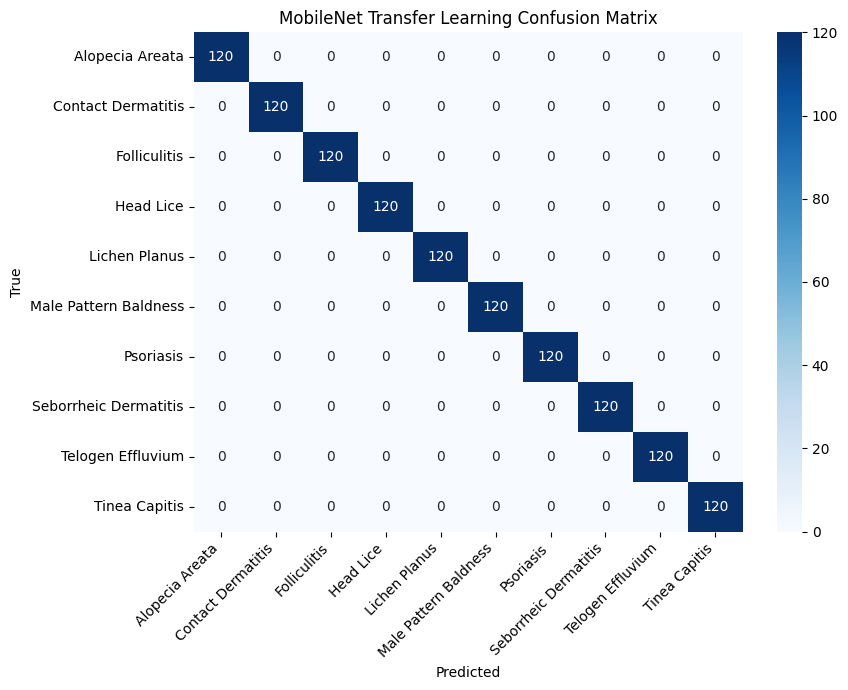

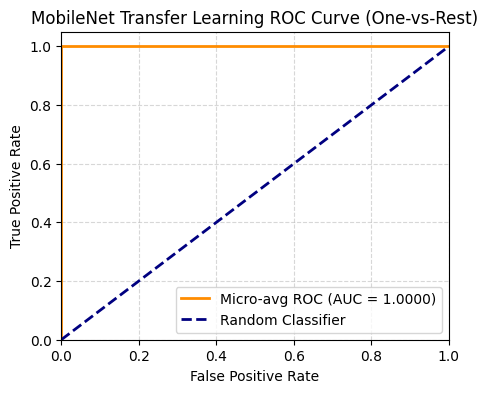

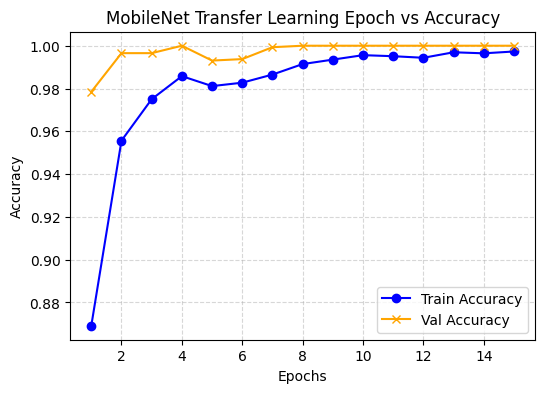

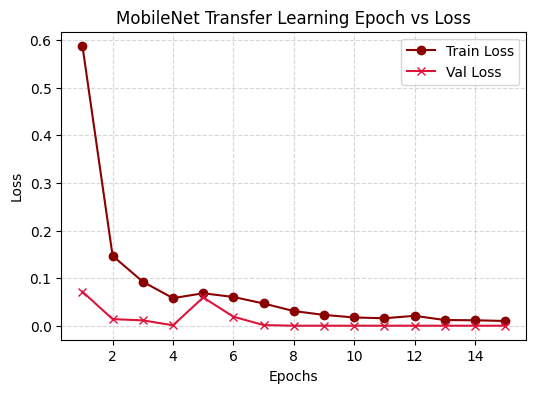

In [13]:
model_mobilenet_tl, base_mb_tl = build_model(MobileNet, deep_head=True)
model_mobilenet_tl.compile(optimizer=Adam(learning_rate=config.LR_SCRATCH),
                           loss='categorical_crossentropy', metrics=['accuracy'])

history_mobilenet_initial = train_model(model_mobilenet_tl, class_weight=class_weights)

base_mb_tl.trainable = True
model_mobilenet_tl.compile(optimizer=Adam(learning_rate=config.LR_TRANSFER),
                           loss='categorical_crossentropy', metrics=['accuracy'])
history_mobilenet_fine = train_model(
    model_mobilenet_tl, epochs=config.FINE_TUNE_EPOCHS, class_weight=class_weights)

master_metrics_registry['MobileNet Transfer Learning'] = evaluate_and_plot(
    model_mobilenet_tl, history_mobilenet_fine, 'MobileNet Transfer Learning')

### 11. ResNet50 - Plain

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 140s 500ms/step - accuracy: 0.1561 - loss: 2.2779 - val_accuracy: 0.2313 - val_loss: 2.1733 - learning_rate: 0.0010
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 124s 485ms/step - accuracy: 0.1940 - loss: 2.2005 - val_accuracy: 0.2590 - val_loss: 2.1163 - learning_rate: 0.0010
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 122s 478ms/step - accuracy: 0.2100 - loss: 2.1711 - val_accuracy: 0.2562 - val_loss: 2.1043 - learning_rate: 0.0010
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 121s 475ms/step - accuracy: 0.2104 - loss: 2.1492 - val_accuracy: 0.2583 - val_loss: 2.0612 - learning_rate: 0.0010
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 121s 476ms/step - accuracy: 0.2223 - loss: 2.1251 - val_accuracy: 0.2625 - val_loss: 2.0661 - learning_rate: 0.0010
Epoch 6/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 124s 487ms/step - accuracy: 0.2297 - loss: 2.1167 - val_accuracy: 0.2326 - val_loss: 2.0434 - learning_rate: 0.0010
Epoch 7/30
25

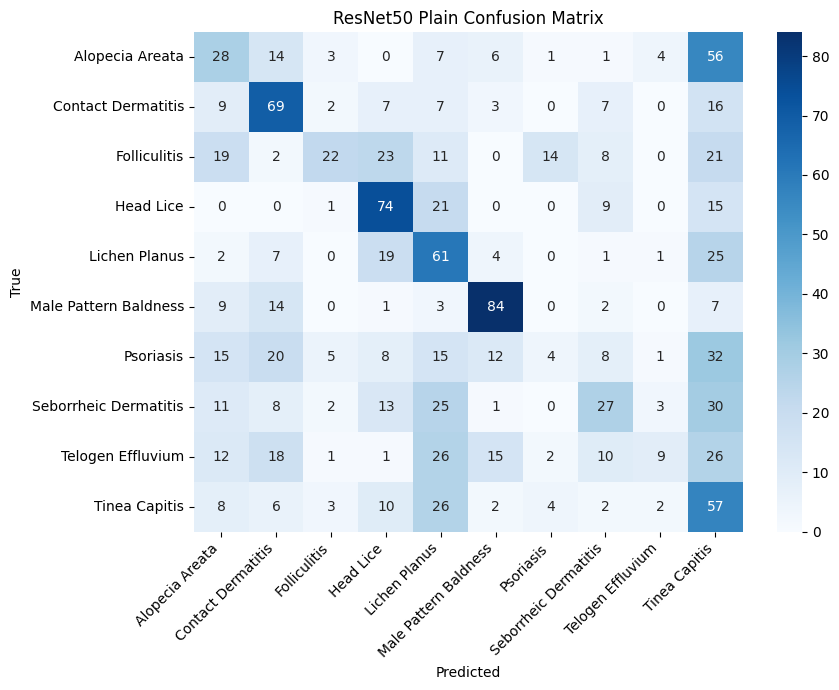

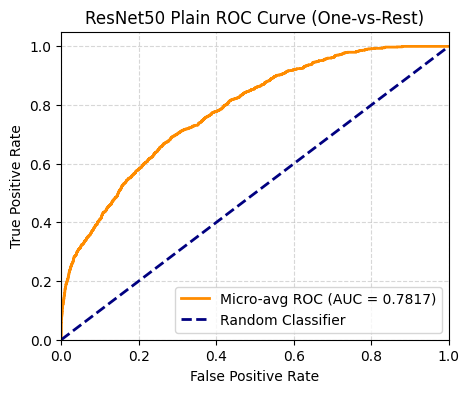

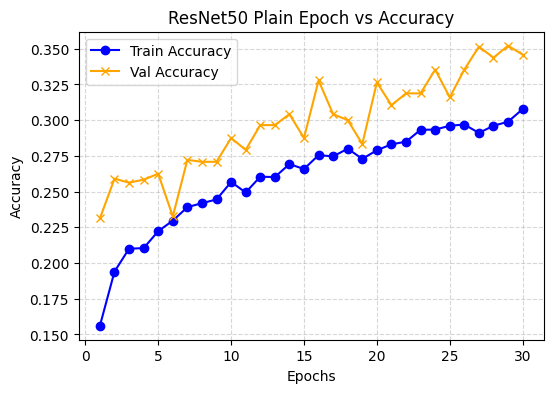

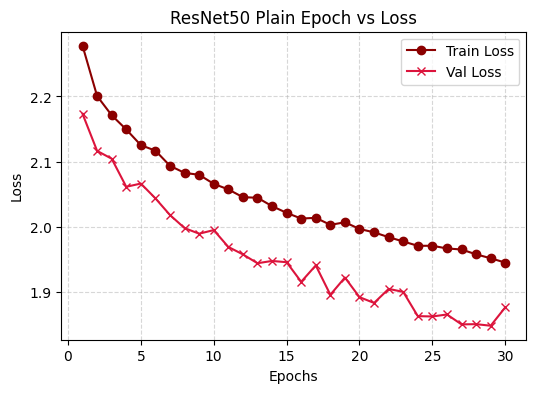

In [14]:
model_resnet, base_rn = build_model(ResNet50, deep_head=False)
model_resnet.compile(optimizer=Adam(learning_rate=config.LR_SCRATCH),
                     loss='categorical_crossentropy', metrics=['accuracy'])

history_resnet = train_model(model_resnet, class_weight=class_weights)

master_metrics_registry['ResNet50 Plain'] = evaluate_and_plot(
    model_resnet, history_resnet, 'ResNet50 Plain')

### 12. ResNet50 - Transfer Learning

Epoch 1/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 140s 497ms/step - accuracy: 0.1070 - loss: 2.3400 - val_accuracy: 0.1514 - val_loss: 2.2939 - learning_rate: 0.0010
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 125s 490ms/step - accuracy: 0.1338 - loss: 2.2854 - val_accuracy: 0.1924 - val_loss: 2.2204 - learning_rate: 0.0010
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 121s 473ms/step - accuracy: 0.1444 - loss: 2.2479 - val_accuracy: 0.1826 - val_loss: 2.1673 - learning_rate: 0.0010
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 119s 465ms/step - accuracy: 0.1560 - loss: 2.2282 - val_accuracy: 0.1979 - val_loss: 2.1584 - learning_rate: 0.0010
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 117s 458ms/step - accuracy: 0.1668 - loss: 2.2021 - val_accuracy: 0.2083 - val_loss: 2.1078 - learning_rate: 0.0010
Epoch 6/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 117s 460ms/step - accuracy: 0.1771 - loss: 2.1823 - val_accuracy: 0.2118 - val_loss: 2.1135 - learning_rate: 0.0010
Epoch 7/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 124s 488ms/step - accura

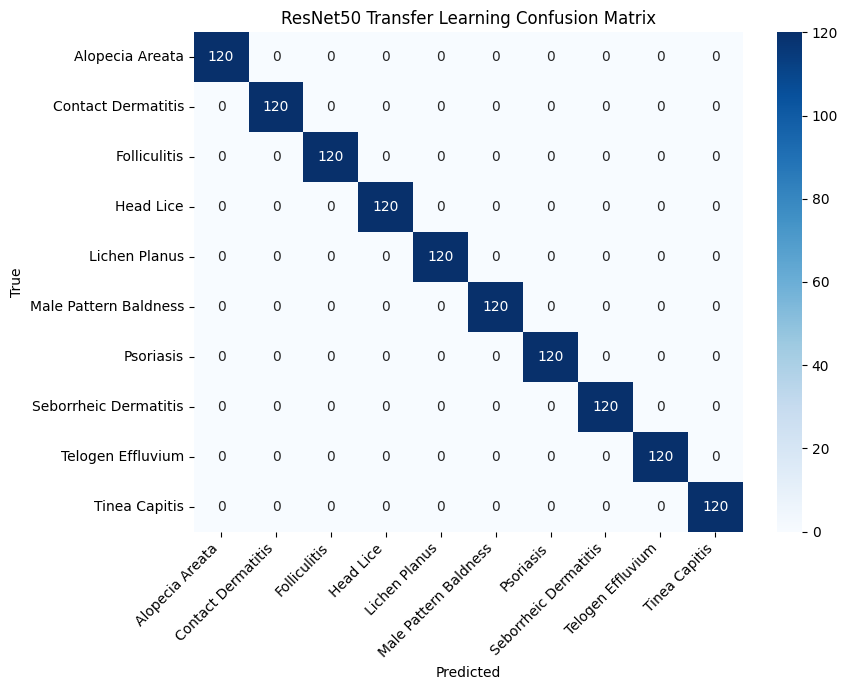

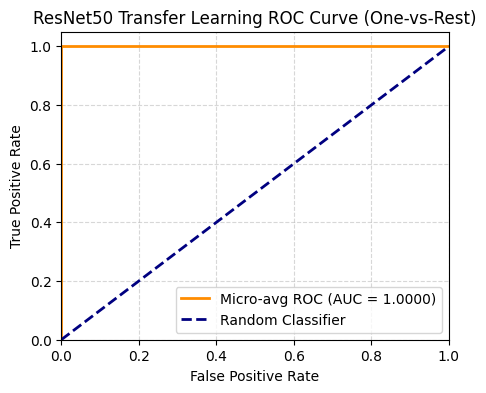

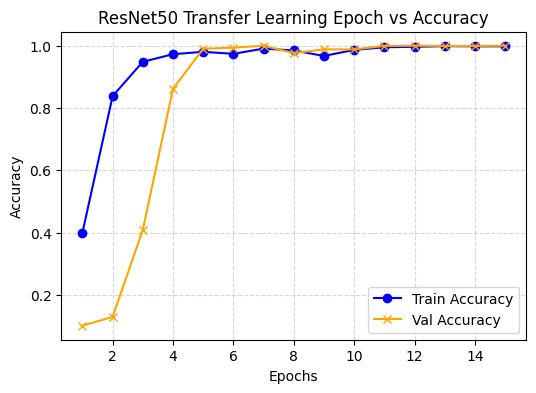

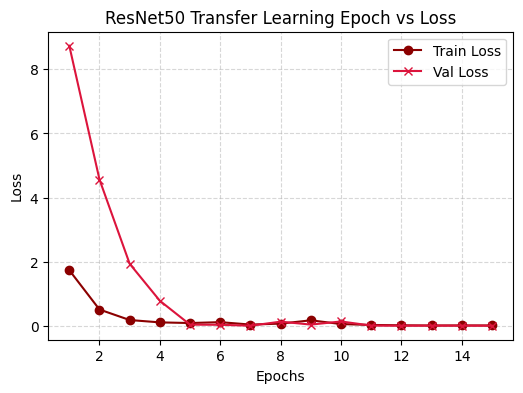

In [15]:
model_resnet_tl, base_rn_tl = build_model(ResNet50, deep_head=True)
model_resnet_tl.compile(optimizer=Adam(learning_rate=config.LR_SCRATCH),
                        loss='categorical_crossentropy', metrics=['accuracy'])

history_resnet_initial = train_model(model_resnet_tl, class_weight=class_weights)

base_rn_tl.trainable = True
model_resnet_tl.compile(optimizer=Adam(learning_rate=config.LR_TRANSFER),
                        loss='categorical_crossentropy', metrics=['accuracy'])
history_resnet_fine = train_model(
    model_resnet_tl, epochs=config.FINE_TUNE_EPOCHS, class_weight=class_weights)

master_metrics_registry['ResNet50 Transfer Learning'] = evaluate_and_plot(
    model_resnet_tl, history_resnet_fine, 'ResNet50 Transfer Learning')

### 13. Hyperparameter Tuning with KerasTuner

Trial 5 Complete [00h 10m 45s]
val_accuracy: 0.23888888955116272

Best val_accuracy So Far: 0.26597222685813904
Total elapsed time: 00h 53m 11s

--- Hyperparameter Optimization Complete ---


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Optimal number of Dense layers: 1
Optimal Learning Rate: 0.0001

Evaluating the Best Hyper-Model:
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - accuracy: 0.2660 - loss: 2.0778
Tuned Model Validation Accuracy: 0.2660

Generating final history for Hyper-Model tracking...
255/255 ━━━━━━━━━━━━━━━━━━━━ 136s 488ms/step - accuracy: 0.2174 - loss: 2.1479 - val_accuracy: 0.2528 - val_loss: 2.0621

================ ResNet50 Hyper-Model RESULTS ================
Accuracy:  0.2425
Loss:      2.0611
Precision: 0.3096
Recall:    0.2425
F1-Score:  0.2018
AUC Score: 0.7112
Latency:   11.32 ms/image


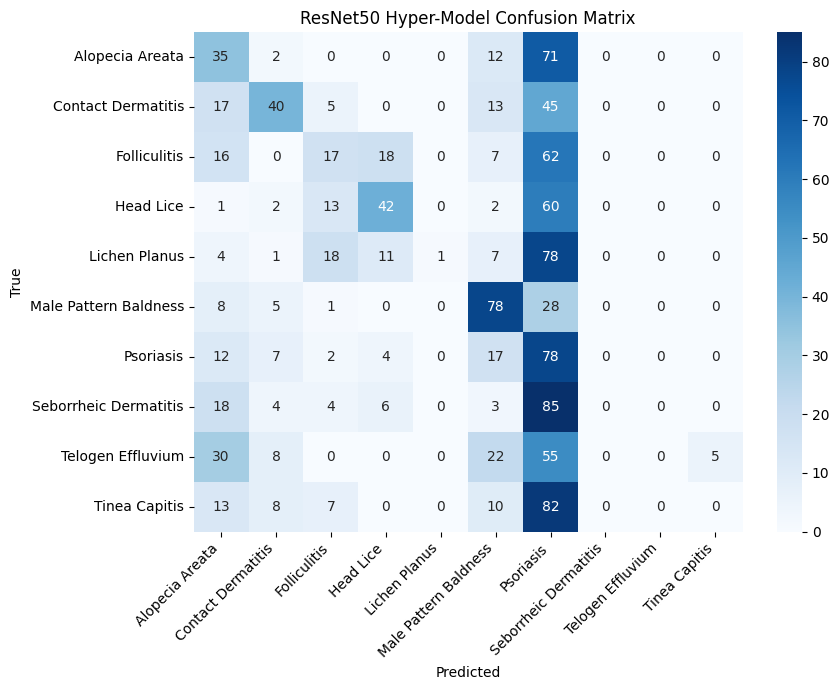

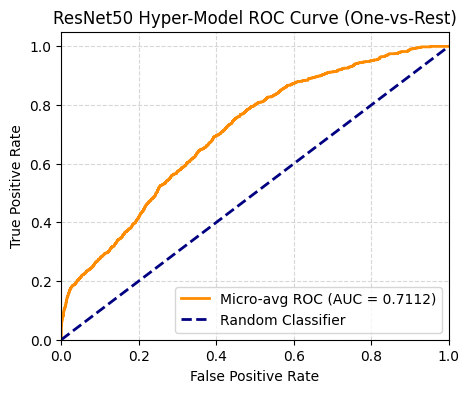

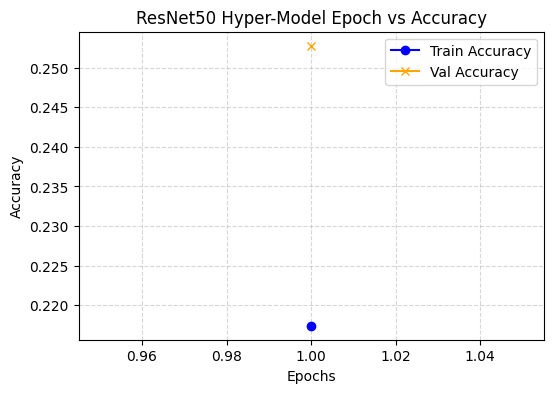

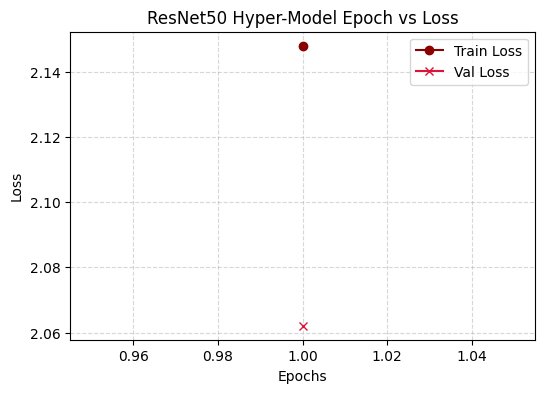

In [16]:
!pip install --quiet keras-tuner

import keras_tuner as kt


def build_hyper_model(hp):
    """ResNet50 backbone with a tunable classification head."""
    base_model = ResNet50(weights='imagenet', include_top=False,
                          input_shape=config.INPUT_SHAPE)
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    for i in range(hp.Int('num_dense_layers', min_value=1, max_value=2)):
        x = Dense(units=hp.Choice(f'dense_units_{i}', values=[256, 512, 1024]),
                  activation='relu')(x)
        x = Dropout(rate=hp.Float(f'dropout_rate_{i}', min_value=0.2,
                                  max_value=0.5, step=0.1))(x)

    outputs = Dense(config.NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=outputs)

    tuned_lr = hp.Choice('learning_rate', values=[1e-3, 1e-4, 5e-5])
    model.compile(optimizer=Adam(learning_rate=tuned_lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


tuner = kt.RandomSearch(
    build_hyper_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='hair_disease_tuning',
    overwrite=True,
)

tuner.search_space_summary()

print('\n--- Starting Hyperparameter Search ---')
tuner.search(
    train_generator,
    epochs=5,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1,
)

print('\n--- Hyperparameter Optimization Complete ---')
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.get_best_models(num_models=1)[0]

print(f"Optimal number of Dense layers: {best_hps.get('num_dense_layers')}")
print(f"Optimal Learning Rate: {best_hps.get('learning_rate')}")

print('\nEvaluating the Best Hyper-Model:')
loss, accuracy = best_model.evaluate(validation_generator, verbose=1)
print(f'Tuned Model Validation Accuracy: {accuracy:.4f}')

# Fit one more epoch to produce a history object for the evaluation plots
print('\nGenerating final history for Hyper-Model tracking...')
history_hyper = best_model.fit(
    train_generator,
    epochs=1,
    validation_data=validation_generator,
    class_weight=class_weights,
    verbose=1,
)

master_metrics_registry['ResNet50 Hyper-Model'] = evaluate_and_plot(
    best_model, history_hyper, 'ResNet50 Hyper-Model')

### 14. Ensemble Model (soft voting, top 3 transfer-learning models)

Generating predictions for DenseNet121...
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step
Generating predictions for MobileNet...
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step
Generating predictions for ResNet50...
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step

     ENSEMBLE MODEL PERFORMANCE METRICS
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000


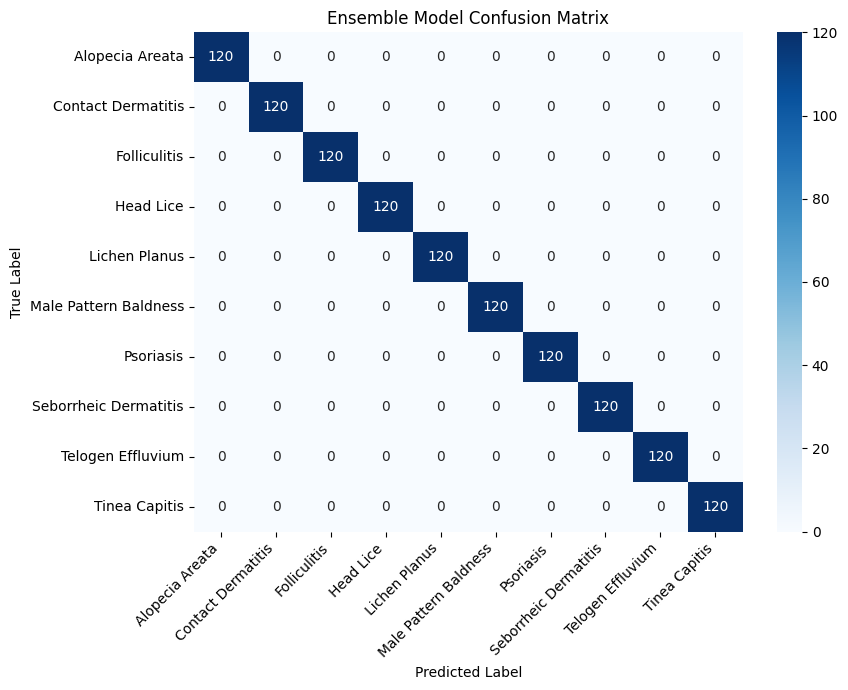

In [17]:
# Average the softmax probabilities of the three fine-tuned models on the TEST set
if hasattr(test_generator, 'reset'):
    test_generator.reset()

print('Generating predictions for DenseNet121...')
preds_densenet = model_densenet_tl.predict(test_generator, verbose=1)
print('Generating predictions for MobileNet...')
preds_mobilenet = model_mobilenet_tl.predict(test_generator, verbose=1)
print('Generating predictions for ResNet50...')
preds_resnet = model_resnet_tl.predict(test_generator, verbose=1)

ensemble_preds = (preds_densenet + preds_mobilenet + preds_resnet) / 3.0
ensemble_pred_classes = np.argmax(ensemble_preds, axis=1)
true_labels = test_generator.classes

ensemble_accuracy = accuracy_score(true_labels, ensemble_pred_classes)
ensemble_precision = precision_score(true_labels, ensemble_pred_classes, average='weighted', zero_division=0)
ensemble_recall = recall_score(true_labels, ensemble_pred_classes, average='weighted', zero_division=0)
ensemble_f1 = f1_score(true_labels, ensemble_pred_classes, average='weighted', zero_division=0)
try:
    ensemble_auc = roc_auc_score(true_labels, ensemble_preds, multi_class='ovr', average='weighted')
except Exception:
    ensemble_auc = np.nan

print('\n' + '=' * 40)
print('     ENSEMBLE MODEL PERFORMANCE METRICS')
print('=' * 40)
print(f'Accuracy:  {ensemble_accuracy:.4f}')
print(f'Precision: {ensemble_precision:.4f}')
print(f'Recall:    {ensemble_recall:.4f}')
print(f'F1-Score:  {ensemble_f1:.4f}')
print(f'ROC-AUC:   {ensemble_auc:.4f}' if not pd.isna(ensemble_auc) else 'ROC-AUC:   N/A')
print('=' * 40)

cm = confusion_matrix(true_labels, ensemble_pred_classes)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Ensemble Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

master_metrics_registry['Voting Ensemble (Top 3)'] = {
    'Model Name': 'Voting Ensemble (Top 3)',
    'Accuracy': float(ensemble_accuracy),
    'Loss': None,
    'Precision': float(ensemble_precision),
    'Recall': float(ensemble_recall),
    'F1-Score': float(ensemble_f1),
    'ROC-AUC': float(ensemble_auc) if not pd.isna(ensemble_auc) else None,
    'Inference Time (ms/img)': None,
    'model_object': None,
    'history_object': None,
}

### 15. Teacher-Student Knowledge Distillation

Extracting soft labels from the teacher ensemble...
Found 9600 images belonging to 10 classes.
Computing predictions from Teacher 1 (DenseNet)...
300/300 ━━━━━━━━━━━━━━━━━━━━ 34s 111ms/step
Computing predictions from Teacher 2 (MobileNet)...
300/300 ━━━━━━━━━━━━━━━━━━━━ 36s 121ms/step
Computing predictions from Teacher 3 (ResNet)...
300/300 ━━━━━━━━━━━━━━━━━━━━ 33s 110ms/step


Model: "Student_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,202 (94.54 KB)

 Trainable params: 24,202 (94.54 KB)

 Non-trainable params: 0 (0.00 B)


--- Starting Student Training via Knowledge Distillation ---
Epoch 1/10 - Distillation Loss: 2.5378
Epoch 2/10 - Distillation Loss: 2.2730
Epoch 3/10 - Distillation Loss: 2.1768
Epoch 4/10 - Distillation Loss: 1.8589
Epoch 5/10 - Distillation Loss: 1.7428
Epoch 6/10 - Distillation Loss: 1.6601
Epoch 7/10 - Distillation Loss: 1.4796
Epoch 8/10 - Distillation Loss: 1.5557
Epoch 9/10 - Distillation Loss: 1.8356
Epoch 10/10 - Distillation Loss: 1.5810

Evaluating the Distilled Student Model on the Test Set:

================ Distilled Student CNN RESULTS ================
Accuracy:  0.1000
Loss:      9.9275
Precision: 0.0100
Recall:    0.1000
F1-Score:  0.0182
AUC Score: 0.4841
Latency:   4.85 ms/image


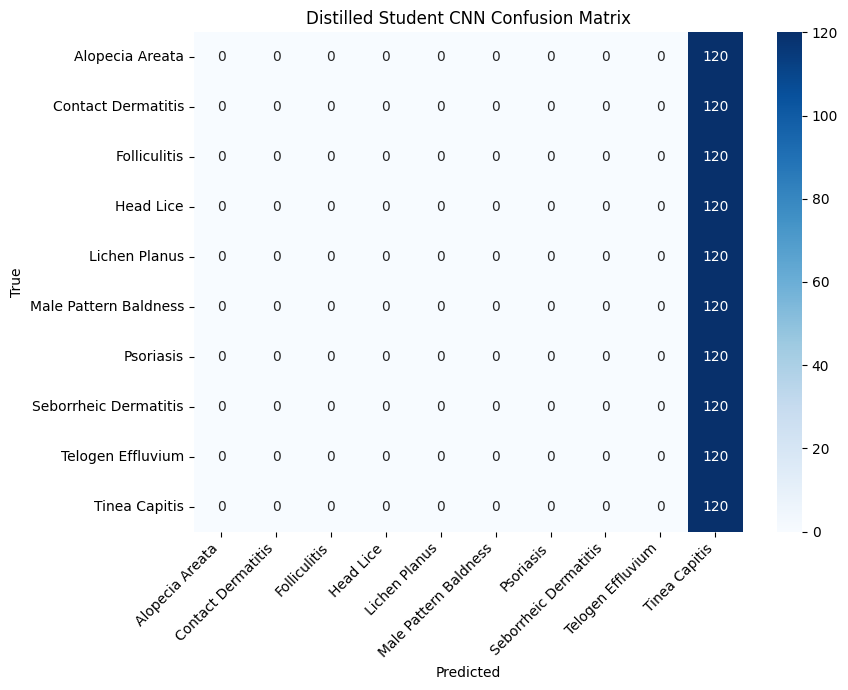

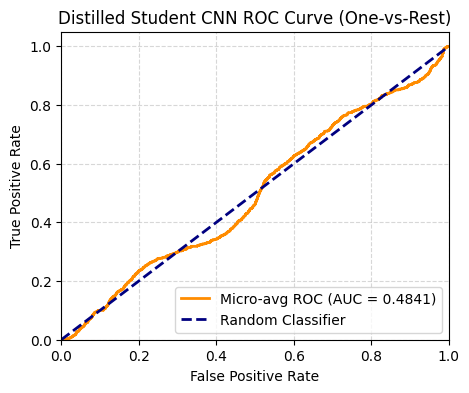

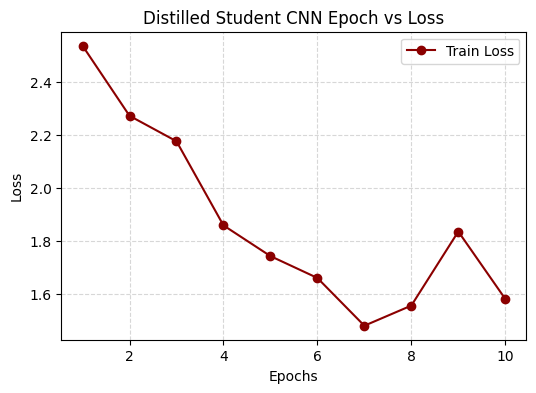

In [18]:
from tensorflow.keras import layers, models

# ---------------------------------------------------------------------
# Step 1: Soft labels from the teacher ensemble over the training data
# ---------------------------------------------------------------------
print('Extracting soft labels from the teacher ensemble...')

# Non-augmented, non-shuffled pass over the whole train directory so predictions
# line up perfectly with the label array.
distill_datagen = ImageDataGenerator(rescale=1./255)
train_generator_distill = distill_datagen.flow_from_directory(
    config.TRAIN_DIR,
    target_size=(config.IMAGE_SIZE, config.IMAGE_SIZE),
    batch_size=config.BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)

train_hard_labels = train_generator_distill.classes                 # int labels
train_hard_onehot = to_categorical(train_hard_labels, config.NUM_CLASSES)

print('Computing predictions from Teacher 1 (DenseNet)...')
preds_t1 = model_densenet_tl.predict(train_generator_distill, verbose=1)
print('Computing predictions from Teacher 2 (MobileNet)...')
preds_t2 = model_mobilenet_tl.predict(train_generator_distill, verbose=1)
print('Computing predictions from Teacher 3 (ResNet)...')
preds_t3 = model_resnet_tl.predict(train_generator_distill, verbose=1)

teacher_soft_labels = (preds_t1 + preds_t2 + preds_t3) / 3.0


# ---------------------------------------------------------------------
# Step 2: Lightweight student model
# ---------------------------------------------------------------------
def build_student_model(input_shape=config.INPUT_SHAPE, num_classes=config.NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs=inputs, outputs=outputs, name='Student_CNN')


student_model = build_student_model()
student_model.summary()


# ---------------------------------------------------------------------
# Step 3: Distillation loss + custom training step
# ---------------------------------------------------------------------
cce = tf.keras.losses.CategoricalCrossentropy()


def distillation_loss(y_true_hard, y_true_soft, y_pred_student, alpha=0.3):
    hard_loss = cce(y_true_hard, y_pred_student)
    soft_loss = cce(y_true_soft, y_pred_student)
    return alpha * hard_loss + (1.0 - alpha) * soft_loss


@tf.function
def train_distillation_step(images, hard_labels, soft_labels, model, optimizer):
    with tf.GradientTape() as tape:
        predictions = model(images, training=True)
        loss = distillation_loss(hard_labels, soft_labels, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss


# ---------------------------------------------------------------------
# Step 4: Train the student
# ---------------------------------------------------------------------
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
epochs = 10
history_loss_logs = []

print('\n--- Starting Student Training via Knowledge Distillation ---')
for epoch in range(epochs):
    epoch_loss = 0.0
    num_samples = 0
    train_generator_distill.reset()

    for step in range(len(train_generator_distill)):
        imgs, _ = next(train_generator_distill)
        batch_size_actual = imgs.shape[0]
        start_idx = step * config.BATCH_SIZE
        end_idx = start_idx + batch_size_actual

        batch_hard = train_hard_onehot[start_idx:end_idx]
        batch_soft = teacher_soft_labels[start_idx:end_idx]

        loss_val = train_distillation_step(
            imgs, batch_hard, batch_soft, student_model, optimizer)

        epoch_loss += float(loss_val) * batch_size_actual
        num_samples += batch_size_actual

    epoch_loss /= num_samples
    history_loss_logs.append(float(epoch_loss))
    print(f'Epoch {epoch + 1}/{epochs} - Distillation Loss: {epoch_loss:.4f}')


# ---------------------------------------------------------------------
# Step 5: Evaluate the distilled student
# ---------------------------------------------------------------------
print('\nEvaluating the Distilled Student Model on the Test Set:')
student_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


class DistillationHistory:
    def __init__(self, loss_history):
        self.history = {'loss': loss_history}


mock_student_history = DistillationHistory(history_loss_logs)

master_metrics_registry['Distilled Student CNN'] = evaluate_and_plot(
    student_model, mock_student_history, 'Distilled Student CNN')

### 16. Performance Comparison: All Trained Models

In [19]:
if 'master_metrics_registry' in globals() and master_metrics_registry:
    raw_dataframe = pd.DataFrame(master_metrics_registry.values())

    columns_to_exclude = ['model_object', 'history_object']
    df_clean_table = raw_dataframe.drop(
        columns=[c for c in columns_to_exclude if c in raw_dataframe.columns], errors='ignore')

    if 'Accuracy' in df_clean_table.columns:
        df_clean_table = df_clean_table.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

    desired_order = ['Model Name', 'Accuracy', 'Loss', 'Precision', 'Recall',
                     'F1-Score', 'ROC-AUC', 'Inference Time (ms/img)']
    existing_columns = [c for c in desired_order if c in df_clean_table.columns]
    extra_columns = [c for c in df_clean_table.columns if c not in desired_order]
    df_clean_table = df_clean_table[existing_columns + extra_columns]

    formatter_matrix = {
        'Accuracy': lambda x: f'{x:.2%}' if pd.notna(x) else 'N/A',
        'Loss': lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A',
        'Precision': lambda x: f'{x:.2%}' if pd.notna(x) else 'N/A',
        'Recall': lambda x: f'{x:.2%}' if pd.notna(x) else 'N/A',
        'F1-Score': lambda x: f'{x:.2%}' if pd.notna(x) else 'N/A',
        'ROC-AUC': lambda x: f'{x:.2%}' if pd.notna(x) else 'N/A',
        'Inference Time (ms/img)': lambda x: f'{x:.2f} ms' if pd.notna(x) else 'N/A',
    }
    active_formatters = {c: fn for c, fn in formatter_matrix.items() if c in df_clean_table.columns}

    print('\n' + '=' * 145)
    print(f"{'COMPLETE DEEP LEARNING BENCHMARK LOG RECORD MATRIX':^145}")
    print('=' * 145)
    print(df_clean_table.to_string(index=False, formatters=active_formatters, justify='center'))
    print('=' * 145)
else:
    print('\n[Metrics Pipeline Alert] master_metrics_registry is empty.')
    print('Run the evaluation cells first.')


                                               COMPLETE DEEP LEARNING BENCHMARK LOG RECORD MATRIX                                                
          Model Name          Accuracy  Loss  Precision  Recall F1-Score ROC-AUC Inference Time (ms/img)
DenseNet121 Transfer Learning 100.00%  0.0000  100.00%  100.00% 100.00%  100.00%         27.20 ms       
      Voting Ensemble (Top 3) 100.00%     NaN  100.00%  100.00% 100.00%  100.00%              NaN       
  MobileNet Transfer Learning 100.00%  0.0000  100.00%  100.00% 100.00%  100.00%          9.80 ms       
   ResNet50 Transfer Learning 100.00%  0.0000  100.00%  100.00% 100.00%  100.00%         12.05 ms       
              MobileNet Plain  99.83%  0.0124   99.83%   99.83%  99.83%  100.00%         11.35 ms       
            DenseNet121 Plain  98.00%  0.0862   98.05%   98.00%  98.00%   99.97%         34.20 ms       
               ResNet50 Plain  36.25%  1.8475   38.56%   36.25%  33.51%   78.17%         11.87 ms       
         ResN

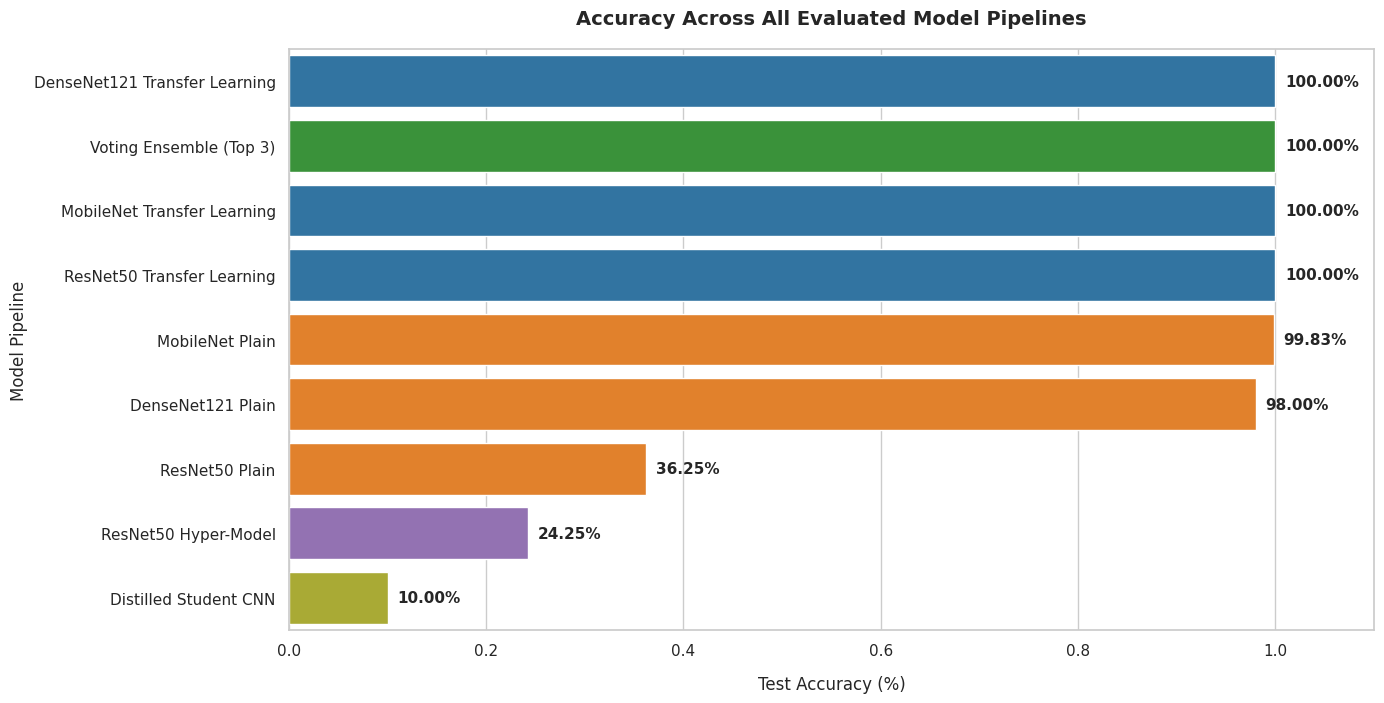

In [20]:
# Paradigm comparison bar chart
if 'master_metrics_registry' in globals() and master_metrics_registry:
    extracted_records = []
    for model_key, payload in master_metrics_registry.items():
        name_lower = model_key.lower()
        if 'ensemble' in name_lower:
            group = 'Ensemble Merge'
        elif 'transfer learning' in name_lower:
            group = 'Transfer Learning'
        elif 'hyper-model' in name_lower or 'tuned' in name_lower:
            group = 'Hyperparameter Tuning'
        elif 'student' in name_lower or 'distilled' in name_lower:
            group = 'Knowledge Distillation'
        else:
            group = 'Plain Scratch'
        extracted_records.append({
            'Model Architecture': model_key,
            'Paradigm Group': group,
            'Accuracy': payload.get('Accuracy'),
        })

    df_final = pd.DataFrame(extracted_records).dropna(subset=['Accuracy'])
    df_final = df_final.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

    color_map = {
        'Ensemble Merge': '#2ca02c',
        'Transfer Learning': '#1f77b4',
        'Hyperparameter Tuning': '#9467bd',
        'Knowledge Distillation': '#bcbd22',
        'Plain Scratch': '#ff7f0e',
    }
    palette_colors = [color_map.get(c, '#7f7f7f') for c in df_final['Paradigm Group']]

    plt.figure(figsize=(14, max(6, len(df_final) * 0.8)))
    sns.set_theme(style='whitegrid')
    ax = sns.barplot(x='Accuracy', y='Model Architecture', data=df_final,
                     palette=palette_colors, hue='Model Architecture', legend=False)
    for bar in ax.patches:
        w = bar.get_width()
        if w > 0:
            ax.text(w + 0.01, bar.get_y() + bar.get_height() / 2,
                    f'{w:.2%}', va='center', ha='left', fontsize=11, weight='bold')
    plt.title('Accuracy Across All Evaluated Model Pipelines', fontsize=14, pad=18, weight='bold')
    plt.xlabel('Test Accuracy (%)', fontsize=12, labelpad=12)
    plt.ylabel('Model Pipeline', fontsize=12)
    plt.xlim(0, 1.1)
    plt.tight_layout()
    plt.show()
else:
    print('\n[System Warning] master_metrics_registry is empty or missing.')

### 17. Master Evaluation Log Table

In [21]:
df_results = pd.DataFrame(master_metrics_registry.values())
df_results = df_results.drop(
    columns=[c for c in ['model_object', 'history_object'] if c in df_results.columns],
    errors='ignore')
df_results = df_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print('=' * 89)
print('                                MASTER EVALUATION LOG TABLE')
print('=' * 89)
print(df_results.to_string(index=False, formatters={
    'Accuracy': lambda x: f'{x:.2%}' if pd.notna(x) else 'N/A',
    'Precision': lambda x: f'{x:.2%}' if pd.notna(x) else 'N/A',
    'Recall': lambda x: f'{x:.2%}' if pd.notna(x) else 'N/A',
    'F1-Score': lambda x: f'{x:.2%}' if pd.notna(x) else 'N/A',
    'ROC-AUC': lambda x: f'{x:.2%}' if pd.notna(x) else 'N/A',
    'Inference Time (ms/img)': lambda x: f'{x:.2f} ms' if pd.notna(x) else 'N/A',
}))

                                MASTER EVALUATION LOG TABLE
                   Model Name Accuracy         Loss Precision  Recall F1-Score ROC-AUC Inference Time (ms/img)
DenseNet121 Transfer Learning  100.00% 2.372127e-07   100.00% 100.00%  100.00% 100.00%                27.20 ms
      Voting Ensemble (Top 3)  100.00%          NaN   100.00% 100.00%  100.00% 100.00%                     NaN
  MobileNet Transfer Learning  100.00% 3.853031e-07   100.00% 100.00%  100.00% 100.00%                 9.80 ms
   ResNet50 Transfer Learning  100.00% 3.460282e-05   100.00% 100.00%  100.00% 100.00%                12.05 ms
              MobileNet Plain   99.83% 1.244512e-02    99.83%  99.83%   99.83% 100.00%                11.35 ms
            DenseNet121 Plain   98.00% 8.624653e-02    98.05%  98.00%   98.00%  99.97%                34.20 ms
               ResNet50 Plain   36.25% 1.847497e+00    38.56%  36.25%   33.51%  78.17%                11.87 ms
         ResNet50 Hyper-Model   24.25% 2.061077e+00 